In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

avax_preds = pd.read_csv('Coin_Models/avax_orders.csv')
near_preds = pd.read_csv('Coin_Models/near_orders.csv')
sol_preds = pd.read_csv('Coin_Models/sol_orders.csv')
dot_preds = pd.read_csv('Coin_Models/dot_orders.csv')
matic_preds = pd.read_csv('Coin_Models/matic_orders.csv')

avax_prices = pd.read_parquet('data/price_data/processed/aval_processed_data.parquet')
dot_prices  = pd.read_parquet('Crypto_QTS_Data_Processed/dot_price_processed.parquet')
matic_prices = pd.read_parquet('data/price_data/processed/matic_processed_data.parquet')
near_prices  = pd.read_parquet('Crypto_QTS_Data_Processed/near_price_processed.parquet')
sol_prices = pd.read_parquet('data/price_data/processed/sol_processed_data.parquet')

In [ ]:
dot_prices['time_period_end'] = dot_prices.index
dot_prices.index = np.arange(len(dot_prices))

near_prices['time_period_end'] = near_prices.index
near_prices.index = np.arange(len(near_prices))

In [3]:
# Define the split index for 70% training data
split_index = len(avax_preds)
avax_prices = avax_prices[-split_index:].reset_index().drop(columns=['index'])
avax_preds['time'] = avax_prices['time_period_end']
avax_preds = avax_preds[(avax_preds['time'] >= '2024-01-01') & (avax_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
avax_prices = avax_prices[(avax_prices['time_period_end'] >= '2024-01-01') & (avax_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(near_preds)
near_prices = near_prices[-split_index:].reset_index().drop(columns=['index'])
near_preds['time'] = near_prices['time_period_end']
near_preds = near_preds[(near_preds['time'] >= '2024-01-01') & (near_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
near_prices = near_prices[(near_prices['time_period_end'] >= '2024-01-01') & (near_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(sol_preds)
sol_prices = sol_prices[-split_index:].reset_index().drop(columns=['index'])
sol_preds['time'] = sol_prices['time_period_end']
sol_preds = sol_preds[(sol_preds['time'] >= '2024-01-01') & (sol_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
sol_prices = sol_prices[(sol_prices['time_period_end'] >= '2024-01-01') & (sol_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(dot_preds)
dot_prices = dot_prices[-split_index:].reset_index().drop(columns=['index'])
dot_preds['time'] = dot_prices['time_period_end']
dot_preds = dot_preds[(dot_preds['time'] >= '2024-01-01') & (dot_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
dot_prices = dot_prices[(dot_prices['time_period_end'] >= '2024-01-01') & (dot_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

split_index = len(matic_preds)
matic_prices = matic_prices[-split_index:].reset_index().drop(columns=['index'])
matic_preds['time'] = matic_prices['time_period_end']
matic_preds = matic_preds[(matic_preds['time'] >= '2024-01-01') & (matic_preds['time'] <= '2024-09-09')].reset_index().drop(columns=['index'])
matic_prices = matic_prices[(matic_prices['time_period_end'] >= '2024-01-01') & (matic_prices['time_period_end'] <= '2024-09-09')].reset_index().drop(columns=['index'])

In [4]:
dfs = {
    "AVAX": avax_preds,
    "NEAR": near_preds,
    "SOL": sol_preds,
    "DOT": dot_preds,
    "MATIC": matic_preds
}

price_dfs = {
    "AVAX": avax_prices,
    "DOT": dot_prices,
    "MATIC": matic_prices,
    "NEAR": near_prices,
    "SOL": sol_prices
}

In [5]:
avax_preds.drop(columns='Unnamed: 0', inplace=True)
near_preds.drop(columns='Unnamed: 0', inplace=True)
sol_preds.drop(columns='Unnamed: 0', inplace=True)
dot_preds.drop(columns='Unnamed: 0', inplace=True)
matic_preds.drop(columns='Unnamed: 0', inplace=True)

In [6]:
'''import pandas as pd
import matplotlib.pyplot as plt

def calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts for each coin based on predicted classifications and probabilities,
    with capital constraints.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}  # Track cash per coin
    coin_holdings = {coin: 0 for coin in coin_names}  # Track stock holdings per coin

    all_results = {} # store results for all coins

    for coin, df in dfs.items():
        results = [] # store results for current coin
        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 100
            prob_sell = row["Probability Sell"] / 100

            investment_amount = 0
            trading_fee = 0.001

            if prediction == 1:  # Buy
                available_cash = coin_cash[coin]
                if available_cash > 0:
                    investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount + (trading_fee * investment_amount)
                    coin_holdings[coin] += investment_amount # track stock holdings
                else:
                    investment_amount = 0 # no cash, no buy

            elif prediction == 2:  # Sell
                available_holdings = coin_holdings[coin]
                if available_holdings > 0:
                  investment_amount = -min(available_holdings, max_investment_per_coin * prob_sell)
                  coin_investments[coin] += investment_amount
                  coin_cash[coin] -= investment_amount # add cash from sale
                  coin_holdings[coin] += investment_amount # reduce stock holdings
                else:
                  investment_amount = 0 # no stock, no sell

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
            })
        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    total_investment = pd.Series([0] * len(next(iter(results.values())))) # initialize with zeros

    for coin_result in results.values():
        total_investment += coin_result['Investment'].cumsum()

    pnl = total_investment
    cumulative_capital = initial_capital + pnl
    return pnl, cumulative_capital

coin_names = list(dfs.keys())

starting_capital = 100000
portfolio_size = len(coin_names) # use number of coins

results = calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cumulative_capital)
plt.title("Cumulative Capital Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("Cumulative Capital")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    display(result_df)'''

'import pandas as pd\nimport matplotlib.pyplot as plt\n\ndef calculate_investment_portfolio(dfs, starting_capital, portfolio_size, coin_names):\n    """\n    Calculates investment amounts for each coin based on predicted classifications and probabilities,\n    with capital constraints.\n    """\n\n    max_investment_per_coin = starting_capital / portfolio_size\n    coin_investments = {coin: 0 for coin in coin_names}\n    coin_cash = {coin: max_investment_per_coin for coin in coin_names}  # Track cash per coin\n    coin_holdings = {coin: 0 for coin in coin_names}  # Track stock holdings per coin\n\n    all_results = {} # store results for all coins\n\n    for coin, df in dfs.items():\n        results = [] # store results for current coin\n        for index, row in df.iterrows():\n            prediction = row["Prediction"]\n            prob_buy = row["Probability Buy"] / 100\n            prob_sell = row["Probability Sell"] / 100\n\n            investment_amount = 0\n            trading_f

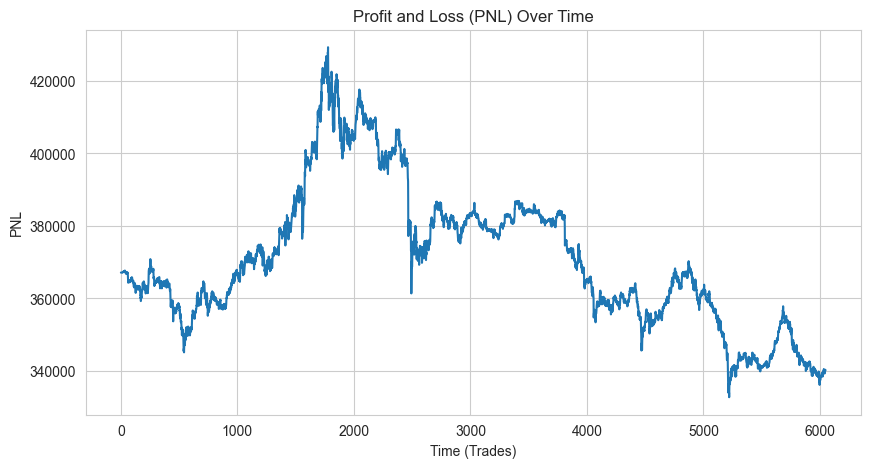


AVAX Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,2.0,0.085139,0.463681,0.0,20000.0,0.000000,0.000000,100000.000000
1,0.0,0.082291,0.427662,0.0,20000.0,0.000000,0.000000,100000.000000
2,2.0,0.089812,0.466062,0.0,20000.0,0.000000,0.000000,100000.000000
3,0.0,0.072257,0.384954,0.0,20000.0,0.000000,0.000000,100000.000000
4,0.0,0.060939,0.314318,0.0,20000.0,0.000000,0.000000,100000.000000
...,...,...,...,...,...,...,...,...
6043,1.0,0.964441,0.005760,0.0,0.0,576.233868,13236.091938,93236.091938
6044,1.0,0.975830,0.003840,0.0,0.0,576.233868,13224.567261,93224.567261
6045,1.0,0.953607,0.007307,0.0,0.0,576.233868,13230.329600,93230.329600
6046,1.0,0.943280,0.010137,0.0,0.0,576.233868,13385.912744,93385.912744



NEAR Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,0.0,0.311442,0.130549,0.0,20000.0,0.000000,0.000000,93299.477664
1,0.0,0.312824,0.131633,0.0,20000.0,0.000000,0.000000,93299.477664
2,0.0,0.306468,0.130114,0.0,20000.0,0.000000,0.000000,93299.477664
3,0.0,0.311780,0.132541,0.0,20000.0,0.000000,0.000000,93299.477664
4,0.0,0.296479,0.130426,0.0,20000.0,0.000000,0.000000,93299.477664
...,...,...,...,...,...,...,...,...
6044,1.0,0.866441,0.036215,0.0,0.0,5562.083637,20579.709457,93879.187121
6045,1.0,0.866355,0.035415,0.0,0.0,5562.083637,20635.330293,93934.807957
6046,1.0,0.858083,0.038974,0.0,0.0,5562.083637,20763.258217,94062.735881
6047,1.0,0.832893,0.046366,0.0,0.0,5562.083637,20796.630719,94096.108383



SOL Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.466601,0.208890,93.320137,19906.679863,0.917422,93.320137,94190.663804
1,1.0,0.466601,0.208890,93.320137,19813.359725,1.832684,186.860456,94190.883986
2,1.0,0.647511,0.089753,129.502177,19683.857548,3.076462,320.321230,94194.842583
3,1.0,0.647511,0.089753,129.502177,19554.355371,4.325037,448.592823,94193.611998
4,1.0,0.411313,0.241141,82.262594,19472.092777,5.123160,528.044142,94190.800724
...,...,...,...,...,...,...,...,...
6043,2.0,0.088192,0.637182,0.000000,20379.048057,0.000000,0.000000,94569.711861
6044,2.0,0.076347,0.707662,0.000000,20379.048057,0.000000,0.000000,94569.711861
6045,2.0,0.076347,0.707662,0.000000,20379.048057,0.000000,0.000000,94569.711861
6046,2.0,0.098808,0.607675,0.000000,20379.048057,0.000000,0.000000,94569.711861



DOT Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.644902,0.213001,128.980410,19871.019590,15.725483,128.980410,94569.711861
1,1.0,0.714220,0.171040,142.843914,19728.175676,33.004292,272.846481,94570.734018
2,1.0,0.652076,0.232251,130.415225,19597.760451,48.728336,404.152821,94571.625134
3,1.0,0.680364,0.204231,136.072874,19461.687577,65.214025,538.276562,94569.676000
4,1.0,0.706567,0.178242,141.313386,19320.374191,82.557347,672.677261,94562.763313
...,...,...,...,...,...,...,...,...
6044,0.0,0.016495,0.041135,0.000000,0.000000,2524.716899,10419.506640,84989.218501
6045,0.0,0.020210,0.039883,0.000000,0.000000,2524.716899,10449.803243,85019.515104
6046,0.0,0.021538,0.038168,0.000000,0.000000,2524.716899,10470.000978,85039.712839
6047,0.0,0.018135,0.039569,0.000000,0.000000,2524.716899,10485.149280,85054.861141



MATIC Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.607117,0.238845,121.423459,19878.576541,125.088554,121.423459,85075.058876
1,1.0,0.614817,0.239633,122.963309,19755.613232,250.178390,245.925358,85076.597465
2,1.0,0.605917,0.248814,121.183336,19634.429896,372.449943,369.135138,85078.623910
3,1.0,0.683847,0.197932,136.769402,19497.660494,511.627110,502.775961,85075.495331
4,1.0,0.712427,0.176876,142.485368,19355.175126,658.853157,637.638085,85067.872087
...,...,...,...,...,...,...,...,...
6043,1.0,0.881203,0.069402,0.000000,0.000000,21905.971459,8175.308548,73250.367425
6044,1.0,0.726888,0.173713,0.000000,0.000000,21905.971459,8190.642728,73265.701605
6045,1.0,0.810618,0.108388,0.000000,0.000000,21905.971459,8199.405117,73274.463993
6046,1.0,0.849266,0.082835,0.000000,0.000000,21905.971459,8212.548700,73287.607576


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

def calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts and PNL for each coin, incorporating price data.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}
    coin_holdings = {coin: 0 for coin in coin_names}
    coin_values = {coin: 0 for coin in coin_names}
    all_results = {}

    for coin, df in dfs.items():
        results = []
        price_df = price_dfs[coin].copy() # make a copy to avoid modifying original
        price_df = price_df.rename(columns={'time_period_end': 'time', 'price_close': 'Close'}) # rename columns
        price_df['time'] = pd.to_datetime(price_df['time']) # ensure datetime
        df['time'] = pd.to_datetime(df['time']) # ensure datetime
        price_df = price_df.set_index('time') # set index to time
        df = df.set_index('time') # set index to time
        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 100
            prob_sell = row["Probability Sell"] / 100
            current_price = price_df.loc[index, 'Close']# if index in price_df.index else price_df['Close'].iloc[price_df.index.get_loc(index, method='ffill')] # get current price, ffill if missing

            investment_amount = 0

            if prediction == 1:  # Buy
                available_cash = coin_cash[coin]
                if available_cash > 0:
                    investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount
                    units_bought = investment_amount / current_price
                    coin_holdings[coin] += units_bought
                else:
                    investment_amount = 0

            elif prediction == 2:  # Sell
                available_holdings = coin_holdings[coin]
                if available_holdings > 0:
                    sell_value = min(available_holdings * current_price, max_investment_per_coin * prob_sell)
                    units_sold = min(available_holdings, sell_value / current_price)
                    investment_amount = -units_sold * current_price
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount
                    coin_holdings[coin] -= units_sold
                else:
                    investment_amount = 0

            coin_values[coin] = coin_holdings[coin] * current_price
            total_coin_value = sum(coin_values.values())
            total_cash = sum(coin_cash.values())
            total_portfolio_value = total_coin_value + total_cash

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
                "Coin Value": coin_values[coin],
                "Total Portfolio Value": total_portfolio_value
            })
        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    pnl = []
    cumulative_capital = []

    first_coin = next(iter(results.values()))
    for index in range(len(first_coin)):
        portfolio_value = 0
        for coin_result in results.values():
            try:
              portfolio_value += coin_result.loc[index, "Total Portfolio Value"]
            except KeyError as e:
              display(coin_result)
              display(first_coin)
              display(index)
              sys.exit(1)
              break

        pnl.append(portfolio_value - initial_capital)
        cumulative_capital.append(portfolio_value)

    return pd.Series(pnl), pd.Series(cumulative_capital)

coin_names = list(dfs.keys())

starting_capital = 100000
portfolio_size = len(coin_names)

results = calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

# Plot PNL and Cumulative Capital
plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    display(result_df)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

def calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names):
    """
    Calculates investment amounts and PNL for each coin, incorporating price data.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}
    coin_holdings = {coin: 0 for coin in coin_names}
    coin_values = {coin: 0 for coin in coin_names}
    all_results = {}

    trading_fee_proportion = 0.001

    for coin, df in dfs.items():
        results = []
        price_df = price_dfs[coin].copy() # make a copy to avoid modifying original
        price_df = price_df.rename(columns={'time_period_end': 'time', 'price_close': 'Close'}) # rename columns
        price_df['time'] = pd.to_datetime(price_df['time']) # ensure datetime
        df['time'] = pd.to_datetime(df['time']) # ensure datetime
        price_df = price_df.set_index('time') # set index to time
        df = df.set_index('time') # set index to time
        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 5
            prob_sell = row["Probability Sell"] / 400
            current_price = price_df.loc[index, 'Close']

            investment_amount = 0

            if prediction == 1:  # Buy
                available_cash = coin_cash[coin]
                min_amount = trading_fee_proportion * min(available_cash, max_investment_per_coin * prob_buy)
                if available_cash >= min_amount:
                    investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                    trading_fee = trading_fee_proportion * investment_amount
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount + trading_fee
                    units_bought = investment_amount / current_price
                    coin_holdings[coin] += units_bought
                else:
                    investment_amount = 0

            elif prediction == 2:  # Sell
                available_holdings = coin_holdings[coin]
                if available_holdings > 0:
                    sell_value = min(available_holdings * current_price, max_investment_per_coin * prob_sell)
                    units_sold = min(available_holdings, sell_value / current_price)
                    investment_amount = -units_sold * current_price
                    trading_fee = trading_fee_proportion * investment_amount
                    coin_investments[coin] += investment_amount
                    coin_cash[coin] -= investment_amount + trading_fee
                    coin_holdings[coin] -= units_sold
                else:
                    investment_amount = 0

            coin_values[coin] = coin_holdings[coin] * current_price
            total_coin_value = sum(coin_values.values())
            total_cash = sum(coin_cash.values())
            total_portfolio_value = total_coin_value + total_cash

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
                "Coin Value": coin_values[coin],
                "Total Portfolio Value": total_portfolio_value
            })
        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    pnl = []
    cumulative_capital = []

    first_coin = next(iter(results.values()))
    for index in range(len(first_coin)):
        portfolio_value = 0
        for coin_result in results.values():
            try:
              portfolio_value += coin_result.loc[index, "Total Portfolio Value"]
            except KeyError as e:
              display(coin_result)
              display(first_coin)
              display(index)
              sys.exit(1)
              break

        pnl.append(portfolio_value - initial_capital)
        cumulative_capital.append(portfolio_value)

    return pd.Series(pnl), pd.Series(cumulative_capital)

coin_names = list(dfs.keys())

starting_capital = 100000
portfolio_size = len(coin_names)

results = calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

# Plot PNL and Cumulative Capital
plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    display(result_df)

"FINAL MODEL"`

Stop-loss triggered for AVAX at 2024-01-12 19:00:00. Sold holdings at 36.45
Stop-loss triggered for AVAX at 2024-01-12 23:00:00. Sold holdings at 35.72
Stop-loss triggered for AVAX at 2024-01-15 00:00:00. Sold holdings at 35.29
Stop-loss triggered for AVAX at 2024-01-15 15:00:00. Sold holdings at 35.48
Stop-loss triggered for AVAX at 2024-01-15 22:00:00. Sold holdings at 35.75
Stop-loss triggered for AVAX at 2024-01-16 14:00:00. Sold holdings at 35.37
Stop-loss triggered for AVAX at 2024-01-18 10:00:00. Sold holdings at 35.39
Stop-loss triggered for AVAX at 2024-01-18 17:00:00. Sold holdings at 34.36
Stop-loss triggered for AVAX at 2024-01-18 19:00:00. Sold holdings at 33.74
Stop-loss triggered for AVAX at 2024-01-19 03:00:00. Sold holdings at 32.96
Stop-loss triggered for AVAX at 2024-01-19 15:00:00. Sold holdings at 33.09
Stop-loss triggered for AVAX at 2024-01-19 17:00:00. Sold holdings at 31.39
Stop-loss triggered for AVAX at 2024-01-20 10:00:00. Sold holdings at 32.07
Stop-loss tr

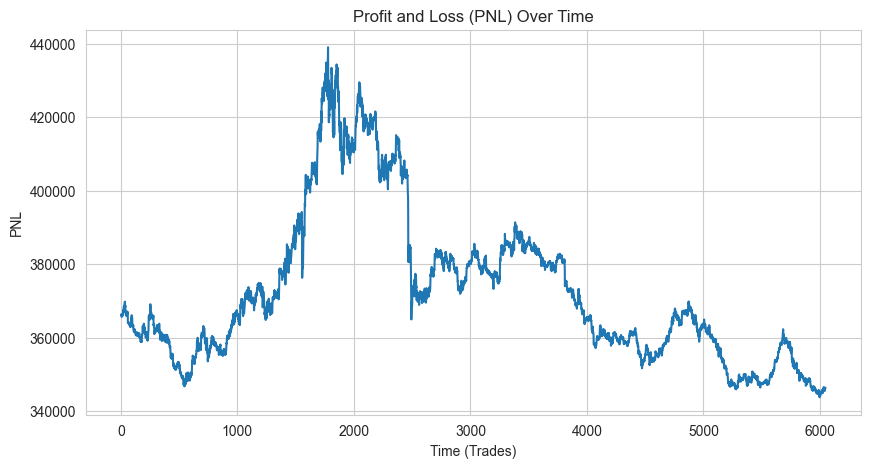


AVAX Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,2.0,0.085139,0.463681,0.0,20000.000000,0.000000,0.000000,100000.000000
1,0.0,0.082291,0.427662,0.0,20000.000000,0.000000,0.000000,100000.000000
2,2.0,0.089812,0.466062,0.0,20000.000000,0.000000,0.000000,100000.000000
3,0.0,0.072257,0.384954,0.0,20000.000000,0.000000,0.000000,100000.000000
4,0.0,0.060939,0.314318,0.0,20000.000000,0.000000,0.000000,100000.000000
...,...,...,...,...,...,...,...,...
6043,1.0,0.964441,0.005760,0.0,-0.001825,464.793221,10676.300292,90676.298467
6044,1.0,0.975830,0.003840,0.0,-0.001825,464.793221,10667.004427,90667.002602
6045,1.0,0.953607,0.007307,0.0,-0.001825,464.793221,10671.652360,90671.650534
6046,1.0,0.943280,0.010137,0.0,-0.001825,464.793221,10797.146529,90797.144704



NEAR Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,0.0,0.311442,0.130549,0.0,20000.000000,0.000000,0.000000,90727.425721
1,0.0,0.312824,0.131633,0.0,20000.000000,0.000000,0.000000,90727.425721
2,0.0,0.306468,0.130114,0.0,20000.000000,0.000000,0.000000,90727.425721
3,0.0,0.311780,0.132541,0.0,20000.000000,0.000000,0.000000,90727.425721
4,0.0,0.296479,0.130426,0.0,20000.000000,0.000000,0.000000,90727.425721
...,...,...,...,...,...,...,...,...
6044,1.0,0.866441,0.036215,0.0,-0.003277,5449.682085,20163.823713,90891.246157
6045,1.0,0.866355,0.035415,0.0,-0.003277,5449.682085,20218.320534,90945.742978
6046,1.0,0.858083,0.038974,0.0,-0.003277,5449.682085,20343.663222,91071.085666
6047,1.0,0.832893,0.046366,0.0,-0.003277,5449.682085,20376.361314,91103.783759



SOL Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.466601,0.208890,1866.402745,18133.410614,18.348434,1866.402745,91196.241714
1,1.0,0.466601,0.208890,1866.402745,16266.821229,36.653679,3737.209115,91200.458698
2,1.0,0.647511,0.089753,2590.043545,13676.518680,61.529241,6406.424606,91279.371640
3,1.0,0.647511,0.089753,2590.043545,11086.216131,86.500737,8971.856454,91254.500939
4,1.0,0.411313,0.241141,1645.251870,9440.799735,102.463208,10560.882846,91198.110935
...,...,...,...,...,...,...,...,...
6043,2.0,0.088192,0.637182,0.000000,22770.577121,0.000000,0.000000,93967.005475
6044,2.0,0.076347,0.707662,0.000000,22770.577121,0.000000,0.000000,93967.005475
6045,2.0,0.076347,0.707662,0.000000,22770.577121,0.000000,0.000000,93967.005475
6046,2.0,0.098808,0.607675,0.000000,22770.577121,0.000000,0.000000,93967.005475



DOT Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.644902,0.213001,2579.608202,17420.133837,314.509656,2579.608202,93966.747514
1,1.0,0.714220,0.171040,2856.878281,14562.969869,660.085836,5456.929610,93986.904954
2,1.0,0.652076,0.232251,2608.304501,11954.404538,974.566726,8083.056428,94004.466441
3,1.0,0.680364,0.204231,2721.457481,9232.674911,1304.280499,10765.531241,93965.211626
4,1.0,0.706567,0.178242,-10627.277508,19859.952418,0.000000,0.000000,93826.957894
...,...,...,...,...,...,...,...,...
6044,0.0,0.016495,0.041135,0.000000,16280.300269,0.000000,0.000000,90247.305744
6045,0.0,0.020210,0.039883,0.000000,16280.300269,0.000000,0.000000,90247.305744
6046,0.0,0.021538,0.038168,0.000000,16280.300269,0.000000,0.000000,90247.305744
6047,0.0,0.018135,0.039569,0.000000,16280.300269,0.000000,0.000000,90247.305744



MATIC Results:


,Prediction,Probability Buy,Probability Sell,Investment,Cash Holdings,Stock Holdings,Coin Value,Total Portfolio Value
0,1.0,0.607117,0.238845,2428.469181,17571.287972,2501.771074,2428.469181,90247.062897
1,1.0,0.614817,0.239633,2459.266186,15111.775860,5003.567804,4918.507151,90277.588755
2,1.0,0.605917,0.248814,2423.666716,12687.866777,7448.998856,7382.702766,90317.875287
3,1.0,0.683847,0.197932,2735.388041,9952.205198,10232.542196,10055.519216,90255.030158
4,1.0,0.712427,0.176876,-9903.054337,19855.259535,0.000000,0.000000,90102.565280
...,...,...,...,...,...,...,...,...
6043,1.0,0.881203,0.069402,0.000000,-0.008628,26811.811472,10006.168041,80253.465158
6044,1.0,0.726888,0.173713,0.000000,-0.008628,26811.811472,10024.936309,80272.233426
6045,1.0,0.810618,0.108388,0.000000,-0.008628,26811.811472,10035.661034,80282.958150
6046,1.0,0.849266,0.082835,0.000000,-0.008628,26811.811472,10051.748121,80299.045237


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
stop_loss_pct = 5


def calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names, stop_loss_pct=.55):
    """
    Calculates investment amounts and PNL for each coin, incorporating price data with stop-loss logic.
    """

    max_investment_per_coin = starting_capital / portfolio_size
    coin_investments = {coin: 0 for coin in coin_names}
    coin_cash = {coin: max_investment_per_coin for coin in coin_names}
    coin_holdings = {coin: 0 for coin in coin_names}
    coin_values = {coin: 0 for coin in coin_names}
    coin_entry_price = {coin: None for coin in coin_names}  # Store initial buy price per coin

    all_results = {}

    trading_fee_proportion = 0.0001
    stop_loss_pct /= 100  # Convert percentage to decimal

    for coin, df in dfs.items():
        results = []
        price_df = price_dfs[coin].copy()
        price_df = price_df.rename(columns={'time_period_end': 'time', 'price_close': 'Close'})
        price_df['time'] = pd.to_datetime(price_df['time'])
        df['time'] = pd.to_datetime(df['time'])
        price_df = price_df.set_index('time')
        df = df.set_index('time')

        for index, row in df.iterrows():
            prediction = row["Prediction"]
            prob_buy = row["Probability Buy"] / 5
            prob_sell = row["Probability Sell"] / 400

            # Ensure index exists in price_df; otherwise, forward-fill the last known price
            if index in price_df.index:
                current_price = price_df.loc[index, 'Close']
            else:
                current_price = price_df['Close'].iloc[price_df.index.get_loc(index, method='ffill')]

            investment_amount = 0
            stop_loss_triggered = False

            # Stop-loss check: If the price drops below stop-loss level, force sell
            if coin_holdings[coin] > 0 and coin_entry_price[coin] is not None:
                stop_loss_price = coin_entry_price[coin] * (1 - stop_loss_pct)
                if current_price < stop_loss_price:
                    sell_value = coin_holdings[coin] * current_price
                    investment_amount = -sell_value
                    coin_cash[coin] += sell_value
                    coin_holdings[coin] = 0  # Liquidate position
                    coin_entry_price[coin] = None  # Reset entry price
                    stop_loss_triggered = True
                    print(f"Stop-loss triggered for {coin} at {index}. Sold holdings at {current_price}")

            # Only proceed with regular buy/sell logic if stop-loss wasn't triggered
            if not stop_loss_triggered:
                if prediction == 1:  # Buy
                    available_cash = coin_cash[coin]
                    if available_cash > 0:
                        investment_amount = min(available_cash, max_investment_per_coin * prob_buy)
                        trading_fee = trading_fee_proportion * investment_amount
                        coin_investments[coin] += investment_amount
                        coin_cash[coin] -= (investment_amount + trading_fee)
                        units_bought = investment_amount / current_price
                        coin_holdings[coin] += units_bought

                        # Set entry price if this is a new position or adjust for additional buys
                        if coin_entry_price[coin] is None:
                            coin_entry_price[coin] = current_price
                        else:
                            # Weighted average entry price for additional purchases
                            prev_value = (coin_holdings[coin] - units_bought) * coin_entry_price[coin]
                            new_value = units_bought * current_price
                            coin_entry_price[coin] = (prev_value + new_value) / coin_holdings[coin]

                elif prediction == 2:  # Sell
                    available_holdings = coin_holdings[coin]
                    if available_holdings > 0:
                        sell_value = min(available_holdings * current_price, max_investment_per_coin * prob_sell)
                        units_sold = min(available_holdings, sell_value / current_price)  # Ensure valid units_sold
                        investment_amount = -units_sold * current_price
                        trading_fee = trading_fee_proportion * abs(investment_amount)
                        coin_investments[coin] += investment_amount
                        coin_cash[coin] += (-investment_amount - trading_fee)  # Add cash from sale
                        coin_holdings[coin] -= units_sold

                        # Reset entry price if all holdings are sold
                        if coin_holdings[coin] == 0:
                            coin_entry_price[coin] = None

            # Update values
            coin_values[coin] = coin_holdings[coin] * current_price
            total_coin_value = sum(coin_values.values())
            total_cash = sum(coin_cash.values())
            total_portfolio_value = total_coin_value + total_cash

            results.append({
                "Prediction": prediction,
                "Probability Buy": row["Probability Buy"],
                "Probability Sell": row["Probability Sell"],
                "Investment": investment_amount,
                "Cash Holdings": coin_cash[coin],
                "Stock Holdings": coin_holdings[coin],
                "Coin Value": coin_values[coin],
                "Total Portfolio Value": total_portfolio_value
            })

        all_results[coin] = pd.DataFrame(results)

    return all_results

def calculate_pnl(results, initial_capital):
    """Calculates PNL and cumulative capital."""
    pnl = []
    cumulative_capital = []

    first_coin = next(iter(results.values()))
    for index in range(len(first_coin)):
        portfolio_value = 0
        for coin_result in results.values():
            try:
              portfolio_value += coin_result.loc[index, "Total Portfolio Value"]
            except KeyError as e:
              display(coin_result)
              display(first_coin)
              display(index)
              sys.exit(1)
              break

        pnl.append(portfolio_value - initial_capital)
        cumulative_capital.append(portfolio_value)

    return pd.Series(pnl), pd.Series(cumulative_capital)

coin_names = list(dfs.keys())
stop_loss_pct = .5
starting_capital = 100000
portfolio_size = len(coin_names)

results = calculate_investment_portfolio(dfs, price_dfs, starting_capital, portfolio_size, coin_names)

pnl, cumulative_capital = calculate_pnl(results, starting_capital)

# Plot PNL and Cumulative Capital
plt.figure(figsize=(10, 5))
plt.plot(pnl)
plt.title("Profit and Loss (PNL) Over Time")
plt.xlabel("Time (Trades)")
plt.ylabel("PNL")
plt.grid(True)
plt.show()

for coin, result_df in results.items():
    print(f"\n{coin} Results:")
    display(result_df)

    Coin Initial Investment Final Value          PNL  PNL (%)
2    SOL         $20,000.00  $22,770.58    $2,770.58   13.85%
1   NEAR         $20,000.00  $20,469.00      $469.00    2.35%
3    DOT         $20,000.00  $16,280.30   $-3,719.70  -18.60%
0   AVAX         $20,000.00  $10,727.43   $-9,272.57  -46.36%
4  MATIC         $20,000.00  $10,062.46   $-9,937.54  -49.69%
5  TOTAL        $100,000.00  $80,309.77  $-19,690.23  -19.69%


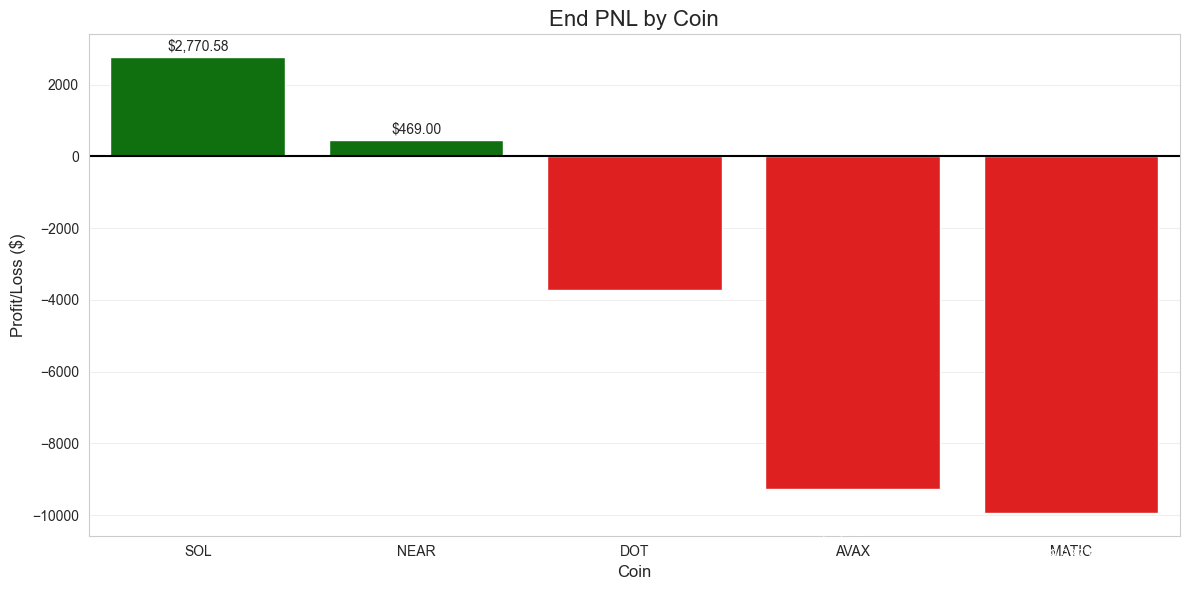

In [31]:
import seaborn as sns

def generate_seaborn_plots(results, pnl, cumulative_capital, price_dfs, stop_loss_events=None):
    """
    Generate enhanced visualizations using Seaborn for portfolio analysis.

    Parameters:
    results (dict): Dictionary of DataFrames with portfolio results for each coin
    pnl (pd.Series): Series containing profit and loss values
    cumulative_capital (pd.Series): Series containing cumulative capital values
    price_dfs (dict): Dictionary of DataFrames containing price data for each coin
    stop_loss_events (dict): Dictionary of DataFrames containing stop loss events for each coin
    """
    # Set the Seaborn theme and color palette
    sns.set_theme(style="darkgrid")

    # 1. Overall PNL and Cumulative Capital Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # PNL plot with color gradient based on positive/negative values
    sns.lineplot(x=range(len(pnl)), y=pnl, ax=ax1, color='blue', linewidth=2)
    ax1.fill_between(range(len(pnl)), 0, pnl, where=(pnl > 0), color='green', alpha=0.3)
    ax1.fill_between(range(len(pnl)), 0, pnl, where=(pnl < 0), color='red', alpha=0.3)
    ax1.set_title("Profit and Loss (PNL) Over Time", fontsize=16)
    ax1.set_ylabel("PNL ($)", fontsize=12)
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)

    # Cumulative Capital plot
    sns.lineplot(x=range(len(cumulative_capital)), y=cumulative_capital, ax=ax2, color='purple', linewidth=2)
    ax2.set_title("Cumulative Capital Over Time", fontsize=16)
    ax2.set_xlabel("Time (Trades)", fontsize=12)
    ax2.set_ylabel("Capital ($)", fontsize=12)

    plt.tight_layout()
    plt.show()

    # 2. Coin Value Distribution Plot
    plt.figure(figsize=(12, 6))
    coin_data = []

    for coin, result_df in results.items():
        for idx, row in result_df.iterrows():
            coin_data.append({
                'Coin': coin,
                'Time': idx,
                'Value': row['Coin Value']
            })

    coin_df = pd.DataFrame(coin_data)

    # Check if we have time as datetime index
    use_pivot = False
    try:
        # Try to create a pivot table with time as index
        pivot_df = coin_df.pivot_table(index='Time', columns='Coin', values='Value', aggfunc='sum')
        use_pivot = True
    except:
        # If that fails, we'll use a different approach
        use_pivot = False

    if use_pivot:
        # Stack plot showing coin value distribution over time
        ax = pivot_df.plot.area(figsize=(12, 6), alpha=0.7, cmap='viridis')
        plt.title('Distribution of Portfolio Value Across Coins Over Time', fontsize=16)
        plt.xlabel('Time', fontsize=12)
        plt.ylabel('Value ($)', fontsize=12)
        plt.legend(title='Coins', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        # Alternative approach using lineplot for each coin
        for coin in coin_df['Coin'].unique():
            coin_subset = coin_df[coin_df['Coin'] == coin]
            plt.plot(range(len(coin_subset)), coin_subset['Value'], label=coin)

        plt.title('Coin Values Over Time', fontsize=16)
        plt.xlabel('Time (Trades)', fontsize=12)
        plt.ylabel('Value ($)', fontsize=12)
        plt.legend(title='Coins')

    plt.tight_layout()
    plt.show()

    # 3. Trade Signal Visualization
    n_coins = len(results)
    fig, axes = plt.subplots(n_coins, 1, figsize=(14, n_coins * 4), sharex=False)

    # Handle case with only one coin
    if n_coins == 1:
        axes = [axes]

    for i, (coin, result_df) in enumerate(results.items()):
        ax = axes[i]

        # Plot holdings over time
        sns.lineplot(x=range(len(result_df)), y=result_df['Coin Value'], ax=ax, color='blue', label='Coin Value')

        # Mark buy and sell points
        buy_points = result_df[result_df['Prediction'] == 1].index
        sell_points = result_df[result_df['Prediction'] == 2].index

        # Convert to position numbers if needed
        try:
            buy_positions = [result_df.index.get_loc(idx) for idx in buy_points]
            sell_positions = [result_df.index.get_loc(idx) for idx in sell_points]
        except:
            buy_positions = list(range(len(buy_points)))
            sell_positions = list(range(len(sell_points)))

        for pos in buy_positions:
            ax.axvline(x=pos, color='green', alpha=0.3, linestyle='--')

        for pos in sell_positions:
            ax.axvline(x=pos, color='red', alpha=0.3, linestyle='--')

        # Mark stop loss events if available
        if stop_loss_events and coin in stop_loss_events:
            stop_loss_points = stop_loss_events[coin].index
            try:
                stop_loss_positions = [result_df.index.get_loc(idx) for idx in stop_loss_points]
                for pos in stop_loss_positions:
                    ax.axvline(x=pos, color='purple', linewidth=2, linestyle='-')
            except:
                pass

        ax.set_title(f"{coin} Value and Trade Signals", fontsize=14)
        ax.set_ylabel("Value ($)", fontsize=12)
        ax.set_xlabel("Time (Trades)", fontsize=12)

        # Create a twin axis for displaying trade actions
        ax2 = ax.twinx()

        # Create markers for trade types
        trade_markers = []
        for idx, row in result_df.iterrows():
            pos = result_df.index.get_loc(idx)

            if row['Stop Loss Triggered']:
                ax2.scatter(pos, 0, color='purple', s=100, marker='x', label='Stop Loss')
            elif row['Prediction'] == 1:  # Buy
                ax2.scatter(pos, 0, color='green', s=80, marker='^', label='Buy')
            elif row['Prediction'] == 2:  # Sell
                ax2.scatter(pos, 0, color='red', s=80, marker='v', label='Sell')

        # Remove duplicate legend entries
        handles, labels = ax2.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax2.legend(by_label.values(), by_label.keys(), loc='upper right')

        # Hide y-axis for the twin axis
        ax2.set_yticks([])

    plt.tight_layout()
    plt.show()

def display_end_pnl_by_coin(results, starting_capital):
    """
    Calculate and display the final PNL for each coin in the portfolio.

    Parameters:
    results (dict): Dictionary of DataFrames with portfolio results for each coin
    starting_capital (float): Initial investment amount

    Returns:
    pd.DataFrame: DataFrame containing end PNL for each coin
    """
    # Calculate initial investment per coin
    coin_names = list(results.keys())
    initial_investment_per_coin = starting_capital / len(coin_names)

    # Prepare data for final PNL calculation
    end_pnl_data = []

    for coin, result_df in results.items():
        # Get the last row for final values
        final_row = result_df.iloc[-1]

        # Calculate end value (cash + holdings)
        end_value = final_row['Cash Holdings'] + final_row['Coin Value']

        # Calculate PNL
        coin_pnl = end_value - initial_investment_per_coin
        coin_pnl_percentage = (coin_pnl / initial_investment_per_coin) * 100

        end_pnl_data.append({
            'Coin': coin,
            'Initial Investment': initial_investment_per_coin,
            'Final Value': end_value,
            'PNL': coin_pnl,
            'PNL (%)': coin_pnl_percentage
        })

    # Create DataFrame and sort by PNL
    end_pnl_df = pd.DataFrame(end_pnl_data)
    end_pnl_df = end_pnl_df.sort_values('PNL', ascending=False)

    # Calculate total portfolio PNL
    total_end_value = sum(row['Final Value'] for row in end_pnl_data)
    total_pnl = total_end_value - starting_capital
    total_pnl_percentage = (total_pnl / starting_capital) * 100

    # Add total row
    end_pnl_df.loc[len(end_pnl_df)] = {
        'Coin': 'TOTAL',
        'Initial Investment': starting_capital,
        'Final Value': total_end_value,
        'PNL': total_pnl,
        'PNL (%)': total_pnl_percentage
    }

    # Format the DataFrame for display
    formatted_df = end_pnl_df.copy()
    formatted_df['Initial Investment'] = formatted_df['Initial Investment'].map('${:,.2f}'.format)
    formatted_df['Final Value'] = formatted_df['Final Value'].map('${:,.2f}'.format)
    formatted_df['PNL'] = formatted_df['PNL'].map('${:,.2f}'.format)
    formatted_df['PNL (%)'] = formatted_df['PNL (%)'].map('{:,.2f}%'.format)

    return formatted_df

# To use this function:
end_pnl_df = display_end_pnl_by_coin(results, starting_capital)
print(end_pnl_df)

# If you want to display it in a visually appealing way with a bar chart:
def plot_end_pnl_by_coin(end_pnl_df):
    """
    Create a bar chart visualization of the end PNL for each coin.
    """
    # Create a copy without the TOTAL row for plotting
    plot_df = end_pnl_df[end_pnl_df['Coin'] != 'TOTAL'].copy()

    # Convert PNL strings back to numeric for plotting
    plot_df['PNL_numeric'] = plot_df['PNL'].str.replace('$', '').str.replace(',', '').astype(float)

    # Set up the plot
    plt.figure(figsize=(12, 6))

    # Create bars with different colors based on positive/negative PNL
    colors = ['green' if x >= 0 else 'red' for x in plot_df['PNL_numeric']]

    # Create the bar chart
    ax = sns.barplot(x='Coin', y='PNL_numeric', data=plot_df, palette=colors)

    # Add value labels on top of each bar
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        if height < 0:
            ax.text(p.get_x() + p.get_width()/2., height - 1000,
                   plot_df['PNL'].iloc[i],
                   ha="center", va="top", color='white')
        else:
            ax.text(p.get_x() + p.get_width()/2., height + 100,
                   plot_df['PNL'].iloc[i],
                   ha="center", va="bottom")

    # Customize the plot
    plt.title('End PNL by Coin', fontsize=16)
    plt.xlabel('Coin', fontsize=12)
    plt.ylabel('Profit/Loss ($)', fontsize=12)
    plt.axhline(y=0, color='black', linestyle='-')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# To show the chart:
plot_end_pnl_by_coin(end_pnl_df)